In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

print("Attention Is All You Need — Implementation")
print("=" * 45)
print()
print("Makale: Vaswani et al. (2017)")
print("arxiv.org/abs/1706.03762")
print()
print("Bugün implement edeceğimiz bileşenler:")
print("1. Scaled Dot-Product Attention")
print("2. Multi-Head Attention")
print("3. Position-wise Feed-Forward Network")
print("4. Positional Encoding")
print("5. Encoder katmanı")
print("6. Tam Encoder")
print()
print("Makale parametreleri:")
print("  d_model = 512")
print("  h = 8 kafa")
print("  d_ff = 2048")
print("  N = 6 katman")

torch.manual_seed(42)

Attention Is All You Need — Implementation

Makale: Vaswani et al. (2017)
arxiv.org/abs/1706.03762

Bugün implement edeceğimiz bileşenler:
1. Scaled Dot-Product Attention
2. Multi-Head Attention
3. Position-wise Feed-Forward Network
4. Positional Encoding
5. Encoder katmanı
6. Tam Encoder

Makale parametreleri:
  d_model = 512
  h = 8 kafa
  d_ff = 2048
  N = 6 katman


In [2]:
# Makale formülü:
# Attention(Q, K, V) = softmax(QK^T / √d_k) * V

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q: (batch, heads, seq_len, d_k)
    K: (batch, heads, seq_len, d_k)
    V: (batch, heads, seq_len, d_v)
    """
    d_k = Q.shape[-1]

    # QK^T / √d_k
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    # Mask uygula (opsiyonel — decoder için)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    # Softmax
    weights = F.softmax(scores, dim=-1)

    # V ile çarp
    output = torch.matmul(weights, V)

    return output, weights

# Test — makale parametreleri
batch_size = 2
seq_len = 10
d_k = 64  # d_model / h = 512 / 8

Q = torch.randn(batch_size, 8, seq_len, d_k)
K = torch.randn(batch_size, 8, seq_len, d_k)
V = torch.randn(batch_size, 8, seq_len, d_k)

output, weights = scaled_dot_product_attention(Q, K, V)

print("=== Scaled Dot-Product Attention ===")
print(f"Q shape: {Q.shape}")
print(f"K shape: {K.shape}")
print(f"V shape: {V.shape}")
print(f"Çıktı shape: {output.shape}")
print(f"Weights shape: {weights.shape}")
print(f"Weights toplamı (her satır): {weights[0,0].sum(dim=-1).round()}")
print()
print("Makale Section 3.2.1 ✅")

=== Scaled Dot-Product Attention ===
Q shape: torch.Size([2, 8, 10, 64])
K shape: torch.Size([2, 8, 10, 64])
V shape: torch.Size([2, 8, 10, 64])
Çıktı shape: torch.Size([2, 8, 10, 64])
Weights shape: torch.Size([2, 8, 10, 10])
Weights toplamı (her satır): tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

Makale Section 3.2.1 ✅


In [3]:
# Makale formülü:
# MultiHead(Q,K,V) = Concat(head_1,...,head_h) * W_O
# head_i = Attention(Q*W_Q_i, K*W_K_i, V*W_V_i)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=512, h=8):
        super().__init__()
        assert d_model % h == 0

        self.d_model = d_model
        self.h = h
        self.d_k = d_model // h  # 512 // 8 = 64

        # Makale: W_Q, W_K, W_V, W_O matrisleri
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        # (batch, seq, d_model) → (batch, h, seq, d_k)
        batch, seq, _ = x.shape
        x = x.view(batch, seq, self.h, self.d_k)
        return x.transpose(1, 2)

    def forward(self, Q, K, V, mask=None):
        batch = Q.shape[0]

        # Lineer projeksiyon
        Q = self.split_heads(self.W_Q(Q))
        K = self.split_heads(self.W_K(K))
        V = self.split_heads(self.W_V(V))

        # Attention
        x, weights = scaled_dot_product_attention(Q, K, V, mask)

        # Kafaları birleştir
        x = x.transpose(1, 2).contiguous()
        x = x.view(batch, -1, self.d_model)

        # Çıkış projeksiyonu
        return self.W_O(x), weights

# Test
d_model = 512
h = 8
seq_len = 10
batch_size = 2

mha = MultiHeadAttention(d_model=d_model, h=h)
x = torch.randn(batch_size, seq_len, d_model)

output, weights = mha(x, x, x)  # Self-attention

print("=== Multi-Head Attention ===")
print(f"Girdi shape:  {x.shape}")
print(f"Çıktı shape:  {output.shape}")
print(f"Weights shape: {weights.shape}")
print(f"d_k = d_model/h = {d_model}/{h} = {d_model//h}")
print()

# Parametre sayısı
params = sum(p.numel() for p in mha.parameters())
print(f"Toplam parametre: {params:,}")
print(f"Teorik: 4 * d_model² = 4 * {d_model}² = {4*d_model**2:,}")
print()
print("Makale Section 3.2.2 ✅")

=== Multi-Head Attention ===
Girdi shape:  torch.Size([2, 10, 512])
Çıktı shape:  torch.Size([2, 10, 512])
Weights shape: torch.Size([2, 8, 10, 10])
d_k = d_model/h = 512/8 = 64

Toplam parametre: 1,050,624
Teorik: 4 * d_model² = 4 * 512² = 1,048,576

Makale Section 3.2.2 ✅


=== Feed-Forward Network ===
Girdi:  torch.Size([2, 10, 512])
Çıktı:  torch.Size([2, 10, 512])
Parametre: 2,099,712
Teorik: 2 * d_model * d_ff = 2 * 512 * 2048 = 2,097,152

Makale Section 3.3 ✅

=== Positional Encoding ===
Girdi:  torch.Size([2, 10, 512])
Çıktı:  torch.Size([2, 10, 512])
Shape değişmedi — PE sadece ekleniyor!


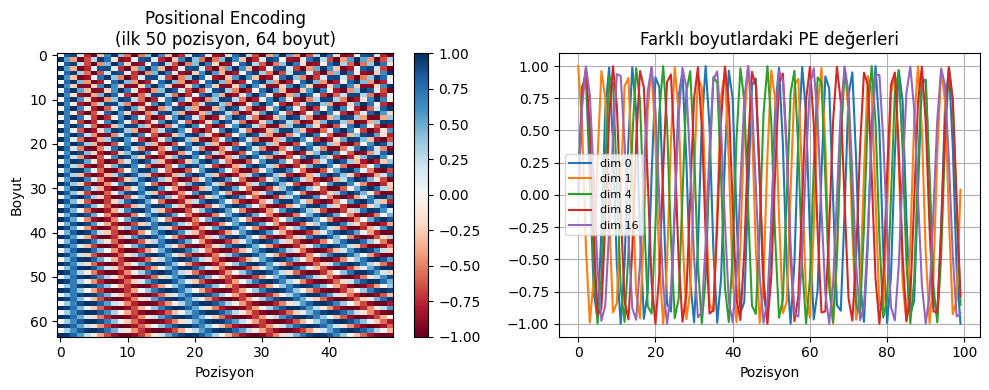

Makale Section 3.5 ✅


In [4]:
# Bileşen 3: Position-wise Feed-Forward Network
# Makale Section 3.3:
# FFN(x) = max(0, xW_1 + b_1)W_2 + b_2
# d_model=512 → d_ff=2048 → d_model=512

class FeedForward(nn.Module):
    def __init__(self, d_model=512, d_ff=2048, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Makale: ReLU aktivasyon
        return self.linear2(self.dropout(F.relu(self.linear1(x))))

# Bileşen 4: Positional Encoding
# Makale Section 3.5:
# PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
# PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

class PositionalEncoding(nn.Module):
    def __init__(self, d_model=512, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # x + PE
        return self.dropout(x + self.pe[:, :x.size(1)])

# Test
ff = FeedForward(d_model=512, d_ff=2048)
pe = PositionalEncoding(d_model=512)

x = torch.randn(2, 10, 512)
ff_out = ff(x)
pe_out = pe(x)

print("=== Feed-Forward Network ===")
print(f"Girdi:  {x.shape}")
print(f"Çıktı:  {ff_out.shape}")
ff_params = sum(p.numel() for p in ff.parameters())
print(f"Parametre: {ff_params:,}")
print(f"Teorik: 2 * d_model * d_ff = 2 * 512 * 2048 = {2*512*2048:,}")
print()
print("Makale Section 3.3 ✅")

print("\n=== Positional Encoding ===")
print(f"Girdi:  {x.shape}")
print(f"Çıktı:  {pe_out.shape}")
print(f"Shape değişmedi — PE sadece ekleniyor!")

# Görselleştir
pe_vis = pe.pe[0].numpy()
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(pe_vis[:50, :64].T, cmap='RdBu', aspect='auto')
plt.colorbar()
plt.title("Positional Encoding\n(ilk 50 pozisyon, 64 boyut)")
plt.xlabel("Pozisyon")
plt.ylabel("Boyut")

plt.subplot(1, 2, 2)
for dim in [0, 1, 4, 8, 16]:
    plt.plot(pe_vis[:100, dim], label=f'dim {dim}')
plt.title("Farklı boyutlardaki PE değerleri")
plt.xlabel("Pozisyon")
plt.legend(fontsize=8)
plt.grid(True)

plt.tight_layout()
plt.show()
print("Makale Section 3.5 ✅")

In [5]:
# Bileşen 5: Encoder Katmanı
# Makale Section 3.1:
# Her katman 2 alt katmandan oluşur:
# 1. Multi-Head Self-Attention
# 2. Feed-Forward Network
# Her birinde: Add & Norm (residual connection + layer norm)

class EncoderLayer(nn.Module):
    def __init__(self, d_model=512, h=8, d_ff=2048, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, h)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # 1. Multi-Head Self-Attention + Add & Norm
        attn_out, weights = self.attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))  # Add & Norm

        # 2. Feed-Forward + Add & Norm
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))    # Add & Norm

        return x, weights

# Bileşen 6: Tam Encoder (N=6 katman)
class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model=512, h=8,
                 d_ff=2048, N=6, dropout=0.1, max_len=512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len, dropout)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, h, d_ff, dropout)
            for _ in range(N)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.scale = math.sqrt(d_model)  # Makale: embedding * √d_model

    def forward(self, x, mask=None):
        # Embedding + Positional Encoding
        x = self.embedding(x) * self.scale
        x = self.pos_encoding(x)

        # N encoder katmanı
        all_weights = []
        for layer in self.layers:
            x, weights = layer(x, mask)
            all_weights.append(weights)

        return self.norm(x), all_weights

# Makale parametreleriyle test
vocab_size = 10000
d_model = 512
N = 6

encoder = TransformerEncoder(
    vocab_size=vocab_size,
    d_model=d_model,
    h=8,
    d_ff=2048,
    N=N
)

# Test
batch_size = 2
seq_len = 20
x = torch.randint(0, vocab_size, (batch_size, seq_len))

output, all_weights = encoder(x)

print("=== Transformer Encoder ===")
print(f"Girdi (token IDs): {x.shape}")
print(f"Çıktı: {output.shape}")
print(f"Katman sayısı: {N}")
print(f"Her katman weights: {all_weights[0].shape}")
print()

total_params = sum(p.numel() for p in encoder.parameters())
print(f"Toplam parametre: {total_params:,}")
print()

# Katman bazlı parametre dağılımı
print("Katman bazlı parametre dağılımı:")
for name, module in encoder.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f"  {name:20s}: {params:>10,}")

print()
print("Makale Section 3.1 ✅")
print("Tam Encoder implement edildi!")

=== Transformer Encoder ===
Girdi (token IDs): torch.Size([2, 20])
Çıktı: torch.Size([2, 20, 512])
Katman sayısı: 6
Her katman weights: torch.Size([2, 8, 20, 20])

Toplam parametre: 24,035,328

Katman bazlı parametre dağılımı:
  embedding           :  5,120,000
  pos_encoding        :          0
  layers              : 18,914,304
  norm                :      1,024

Makale Section 3.1 ✅
Tam Encoder implement edildi!


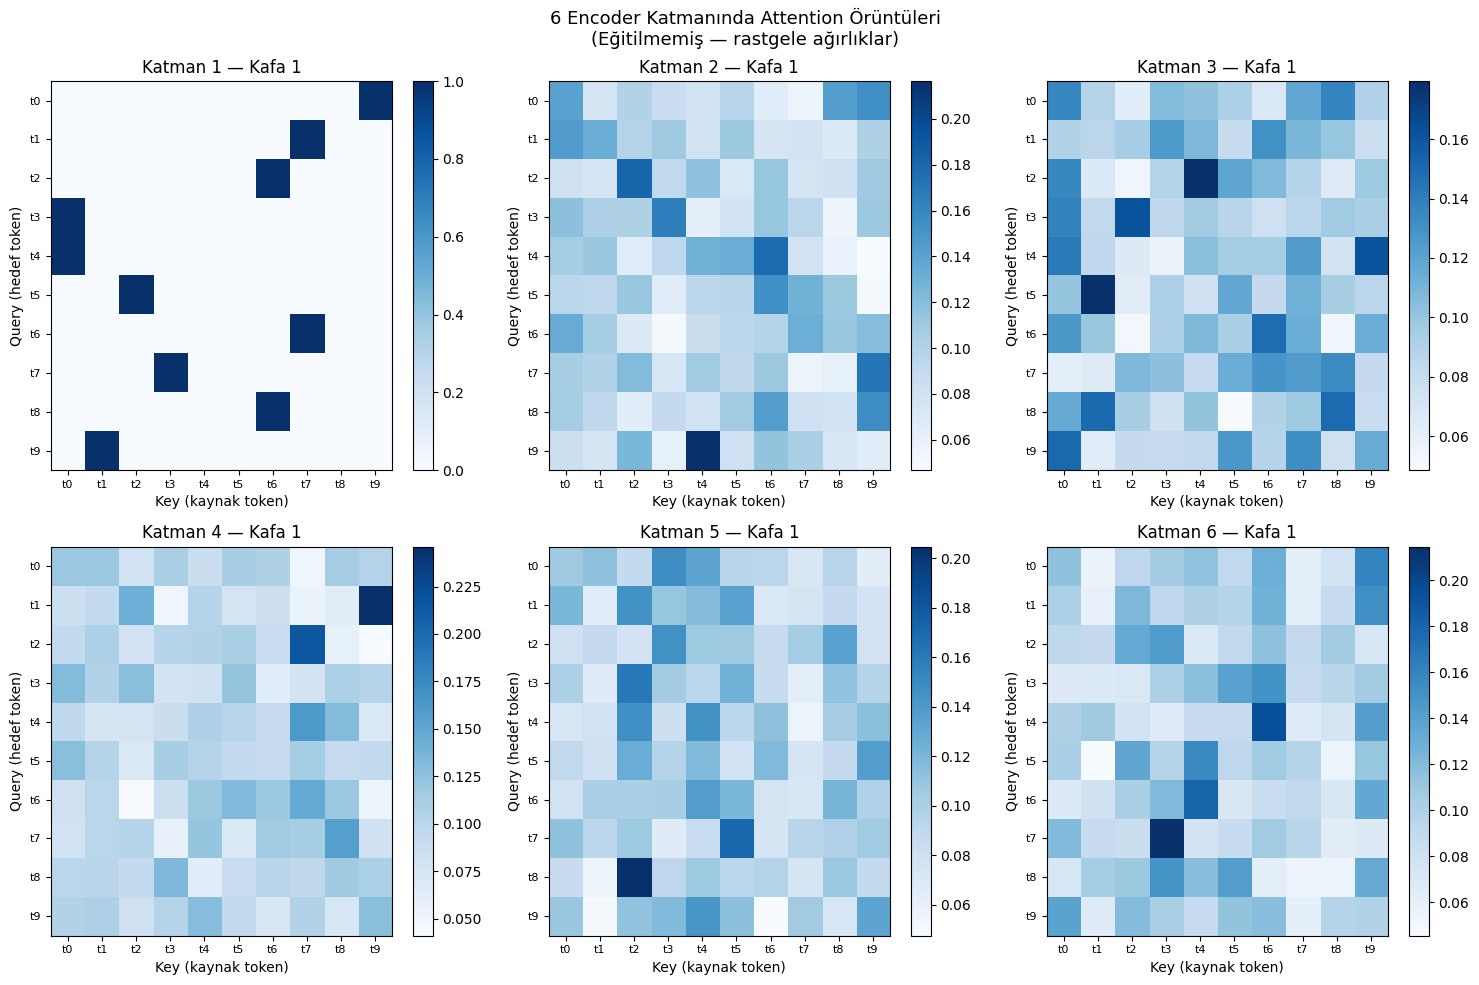

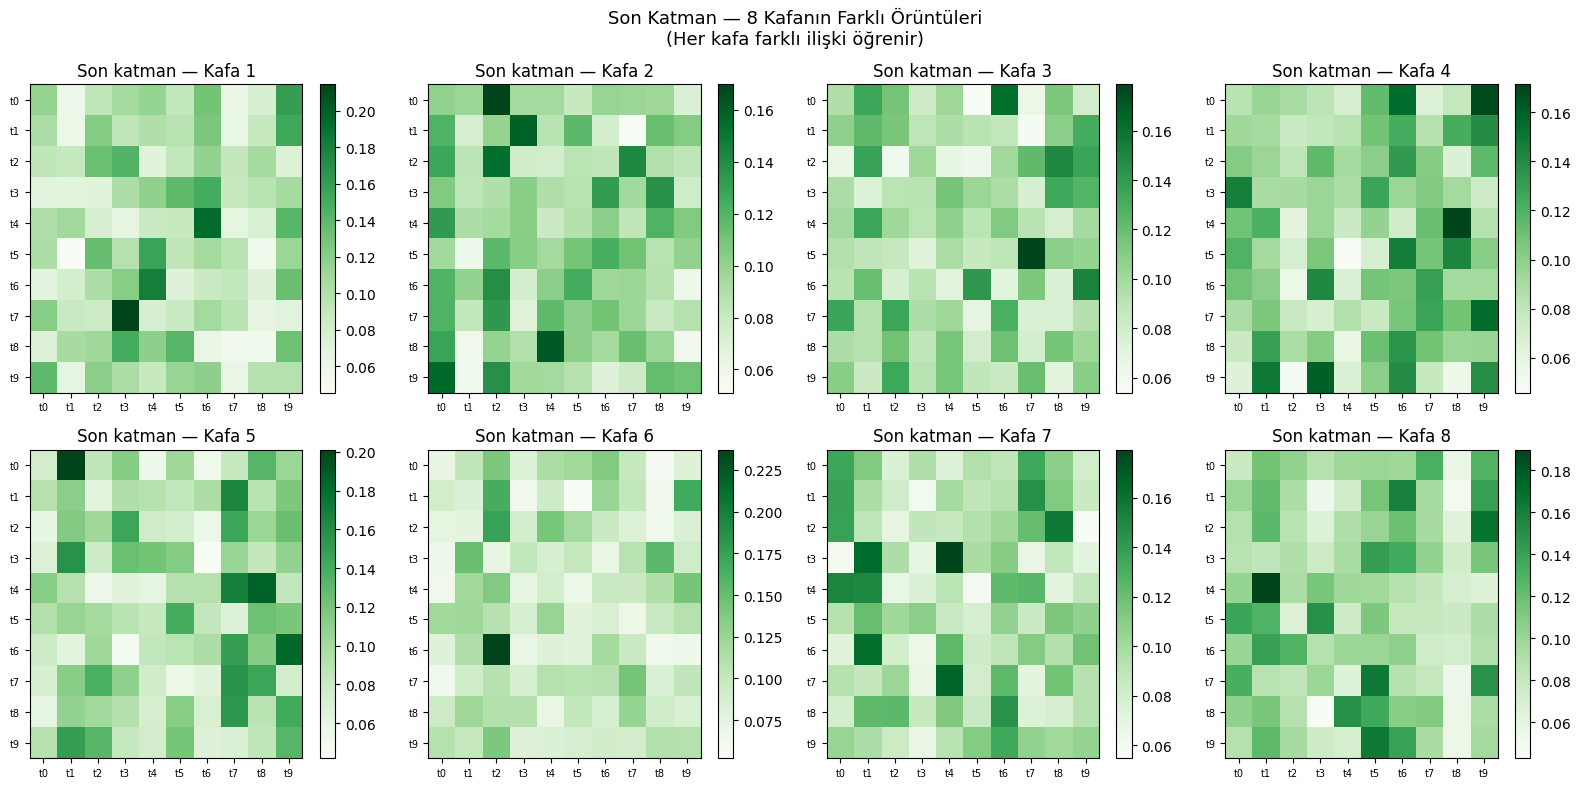

Özet — Implement Edilen Bileşenler:
✅ Scaled Dot-Product Attention  (Section 3.2.1)
✅ Multi-Head Attention           (Section 3.2.2)
✅ Feed-Forward Network           (Section 3.3)
✅ Positional Encoding            (Section 3.5)
✅ Encoder Layer                  (Section 3.1)
✅ Tam Encoder (N=6)              (Section 3.1)

Makaledeki her formülü kodla ifade ettik!


In [6]:
# ATTENTION GÖRSELLEŞTIRME
# Encoder'ın farklı katmanlarındaki attention örüntüleri

encoder.eval()

# Örnek cümle — token ID'leri
np.random.seed(42)
cümle_len = 10
x_vis = torch.randint(0, vocab_size, (1, cümle_len))

with torch.no_grad():
    output, all_weights = encoder(x_vis)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for katman_idx, ax in enumerate(axes.flatten()):
    # İlk batch, ilk kafa
    w = all_weights[katman_idx][0, 0].numpy()
    im = ax.imshow(w, cmap='Blues', aspect='auto')
    ax.set_title(f"Katman {katman_idx+1} — Kafa 1")
    ax.set_xlabel("Key (kaynak token)")
    ax.set_ylabel("Query (hedef token)")
    ax.set_xticks(range(cümle_len))
    ax.set_yticks(range(cümle_len))
    ax.set_xticklabels([f"t{i}" for i in range(cümle_len)], fontsize=8)
    ax.set_yticklabels([f"t{i}" for i in range(cümle_len)], fontsize=8)
    plt.colorbar(im, ax=ax)

plt.suptitle("6 Encoder Katmanında Attention Örüntüleri\n(Eğitilmemiş — rastgele ağırlıklar)",
             fontsize=13)
plt.tight_layout()
plt.show()

# Farklı kafalar — son katman
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for kafa_idx, ax in enumerate(axes.flatten()):
    w = all_weights[-1][0, kafa_idx].numpy()
    im = ax.imshow(w, cmap='Greens', aspect='auto')
    ax.set_title(f"Son katman — Kafa {kafa_idx+1}")
    ax.set_xticks(range(cümle_len))
    ax.set_yticks(range(cümle_len))
    ax.set_xticklabels([f"t{i}" for i in range(cümle_len)], fontsize=7)
    ax.set_yticklabels([f"t{i}" for i in range(cümle_len)], fontsize=7)
    plt.colorbar(im, ax=ax)

plt.suptitle("Son Katman — 8 Kafanın Farklı Örüntüleri\n(Her kafa farklı ilişki öğrenir)",
             fontsize=13)
plt.tight_layout()
plt.show()

print("Özet — Implement Edilen Bileşenler:")
print("✅ Scaled Dot-Product Attention  (Section 3.2.1)")
print("✅ Multi-Head Attention           (Section 3.2.2)")
print("✅ Feed-Forward Network           (Section 3.3)")
print("✅ Positional Encoding            (Section 3.5)")
print("✅ Encoder Layer                  (Section 3.1)")
print("✅ Tam Encoder (N=6)              (Section 3.1)")
print()
print("Makaledeki her formülü kodla ifade ettik!")